# Email Spam Detection using Machine Learning

### Oasis Infobyte Internship

Author: Muhammad Danish

Task 4

This project builds a Natural Language Processing (NLP) model that classifies SMS messages into Spam and Ham using TF-IDF Vectorization and Machine Learning algorithms.

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import string
import re


from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

**Load Dataset**

In [11]:
df = pd.read_csv("dataset/spam.csv", encoding="latin-1")

print(df.head(10))

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   
5  spam  FreeMsg Hey there darling it's been 3 week's n...        NaN   
6   ham  Even my brother is not like to speak with me. ...        NaN   
7   ham  As per your request 'Melle Melle (Oru Minnamin...        NaN   
8  spam  WINNER!! As a valued network customer you have...        NaN   
9  spam  Had your mobile 11 months or more? U R entitle...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
5        NaN        NaN  
6        NaN  

In [12]:
#shape of data

print(df.shape)

(5572, 5)


**data cleaning**

In [13]:
# info of data to get null or null values and data types of columns

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB
None


In [14]:
# drop unnecessary columns last 3 columns

df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [15]:
df.sample(10)

,v1,v2
2133,ham,Spoke with uncle john today. He strongly feels...
5317,ham,"K, fyi I'm back in my parents' place in south ..."
1573,spam,SMS AUCTION - A BRAND NEW Nokia 7250 is up 4 a...
2756,ham,Have a good trip. Watch out for . Remember whe...
1885,ham,I think asking for a gym is the excuse for laz...
2747,ham,Ya had just now.onion roast.
5544,ham,"I'm taking derek &amp; taylor to walmart, if I..."
3327,ham,No we put party 7 days a week and study lightl...
3886,ham,Cab is available.they pick up and drop at door...
1837,ham,And how's your husband.


In [16]:
# rename columns to make it more readable

df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)

In [17]:
df.sample(10)

,target,text
1854,ham,They did't play one day last year know even th...
1077,ham,"Yep, by the pretty sculpture"
3448,ham,Sorry. || mail? ||
607,ham,what I meant to say is cant wait to see u agai...
618,ham,I come n pick Ì_ up... Come out immediately af...
2311,spam,Congratulations! Thanks to a good friend U hav...
3589,ham,I am in escape theatre now. . Going to watch K...
2431,ham,That's good. Lets thank God. Please complete t...
3614,ham,I enjoy watching and playing football and bask...
1896,ham,I tot u outside cos darren say u come shopping...


In [ ]:
# rename column of target to 0 and 1 for ham and spam

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['target'] = encoder.fit_transform(df['target'])

# 0 for ham and 1 for spam


In [22]:
df.sample(10)

,target,text
1228,1,FREE entry into our å£250 weekly comp just sen...
2430,0,How was txting and driving
4769,0,CHEERS LOU! YEAH WAS A GOODNITE SHAME U NEVA C...
822,1,"SMSSERVICES. for yourinclusive text credits, p..."
846,0,My stomach has been thru so much trauma I swea...
3119,0,Good evening! this is roger. How are you?
833,0,Thank you so much. When we skyped wit kz and s...
3203,0,She's good. How are you. Where r u working now
4306,0,I guess it is useless calling u 4 something im...
207,0,"Aight yo, dats straight dogg"


In [23]:
# check missing values

df.isnull().sum()

target    0
text      0
dtype: int64

In [25]:
# check for duplicates

print(df.duplicated().sum())

403


In [26]:
# droping duplicates

df = df.drop_duplicates(keep='first')

In [27]:
print(df.duplicated().sum())

0


In [ ]:
#final shape of data after cleaning
df.shape

(5169, 2)

**EDA**

In [29]:
df.head(10)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
5,1,FreeMsg Hey there darling it's been 3 week's n...
6,0,Even my brother is not like to speak with me. ...
7,0,As per your request 'Melle Melle (Oru Minnamin...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...


In [30]:
# check how many ham and spam messages are there in the dataset

df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

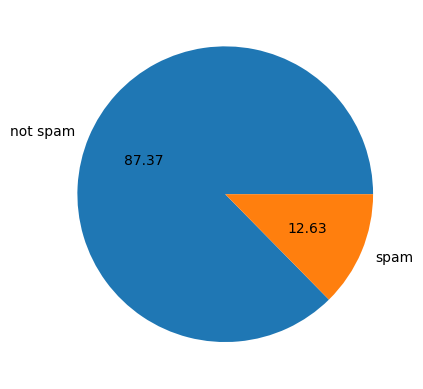

In [32]:
plt.pie(df['target'].value_counts(), labels=['not spam', 'spam'], autopct="%0.2f")
plt.show()

In [44]:
# data is imbalanced

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Alpha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Alpha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [ ]:
# count words in text column and create a new column for it
df['text_char'] = df['text'].apply(len)
df.head(10)

,target,text,text_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
5,1,FreeMsg Hey there darling it's been 3 week's n...,148
6,0,Even my brother is not like to speak with me. ...,77
7,0,As per your request 'Melle Melle (Oru Minnamin...,160
8,1,WINNER!! As a valued network customer you have...,158
9,1,Had your mobile 11 months or more? U R entitle...,154


In [47]:
# now count words in text column and create a new column for it
df['text_word_count'] = df['text'].apply(lambda x:len(nltk.word_tokenize(str(x))))


In [48]:
df.head(10)

,target,text,text_char,text_word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
5,1,FreeMsg Hey there darling it's been 3 week's n...,148,39
6,0,Even my brother is not like to speak with me. ...,77,18
7,0,As per your request 'Melle Melle (Oru Minnamin...,160,31
8,1,WINNER!! As a valued network customer you have...,158,32
9,1,Had your mobile 11 months or more? U R entitle...,154,31


In [49]:
# no of sentences in text column and create a new column for it
df['text_sentence_count'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(str(x))))

In [50]:
df.sample(10)

,target,text,text_char,text_word_count,text_sentence_count
3603,0,Hey morning what you come to ask:-) pa...,41,12,1
146,1,FreeMsg Why haven't you replied to my text? I'...,159,35,3
2070,1,Sexy Singles are waiting for you! Text your AG...,149,33,3
4177,0,Two teams waiting for some players,34,6,1
2978,1,"Xmas Offer! Latest Motorola, SonyEricsson & No...",159,29,4
61,0,Ha ha ha good joke. Girls are situation seekers.,48,11,2
5313,0,My sister going to earn more than me da.,40,10,1
5300,0,I can't make it tonight,23,6,1
2778,1,For ur chance to win a å£250 cash every wk TXT...,124,27,2
3853,0,oh ya... Got hip hop open. Haha i was thinking...,148,35,2


In [52]:
#describe the data to get the statistical information of the data

df[['text_char', 'text_word_count', 'text_sentence_count']].describe()

,text_char,text_word_count,text_sentence_count
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
# analyze the data to get the statistical information of the data
# seperate the data into ham and spam to analyze the data

# not spam emails

df[df['target'] == 0][['text_char', 'text_word_count', 'text_sentence_count']].describe()

,text_char,text_word_count,text_sentence_count
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [54]:
# spam emails

df[df['target'] == 1][['text_char', 'text_word_count', 'text_sentence_count']].describe()

,text_char,text_word_count,text_sentence_count
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='text_char', ylabel='Count'>

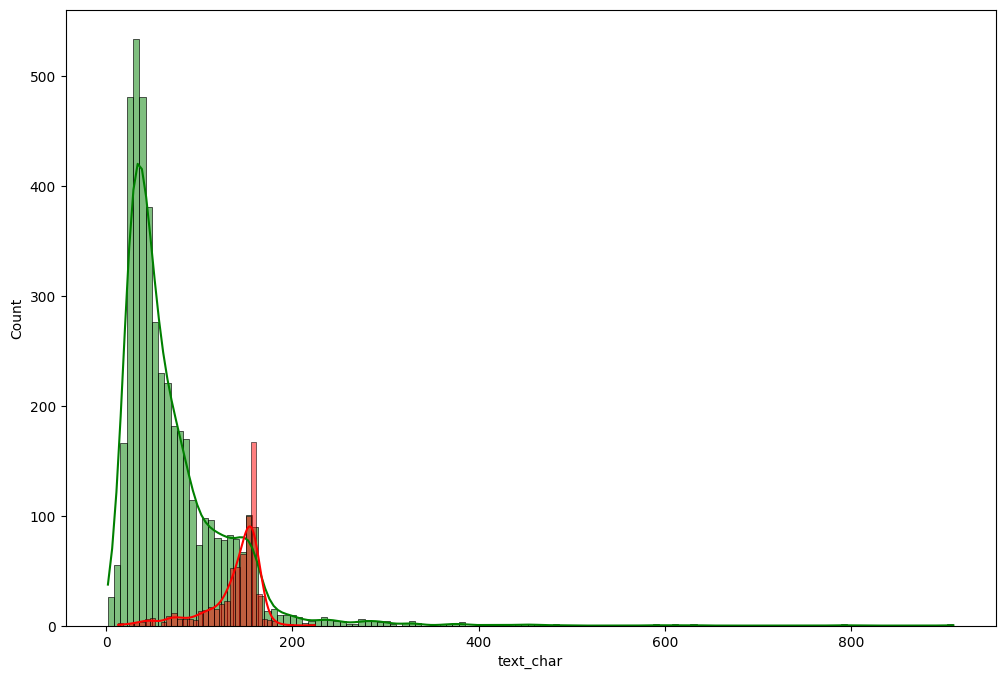

In [60]:
#plot histogram for not spam emails and spam emails to compare the distribution of text_char, text_word_count and text_sentence_count

plt.figure(figsize=(12,8))
sns.histplot(df[df['target'] == 0]['text_char'], color='green', label='not spam', kde=True)
sns.histplot(df[df['target'] == 1]['text_char'], color='red', label='spam', kde=True)

<Axes: xlabel='text_word_count', ylabel='Count'>

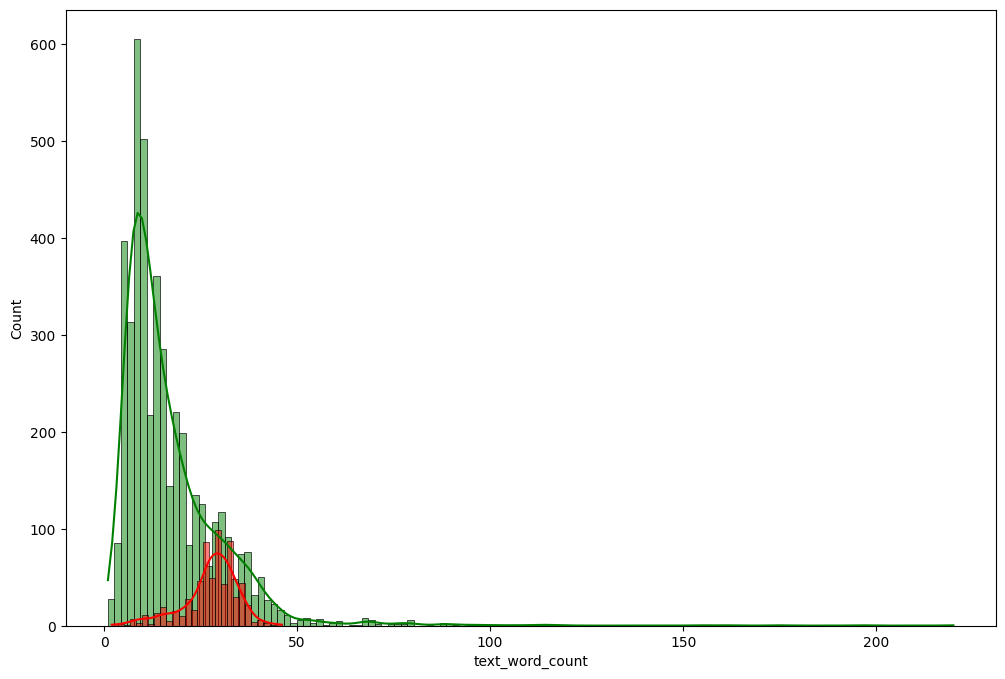

In [61]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target'] == 0]['text_word_count'], color='green', label='not spam', kde=True)
sns.histplot(df[df['target'] == 1]['text_word_count'], color='red', label='spam', kde=True)

<Figure size 1200x800 with 0 Axes>

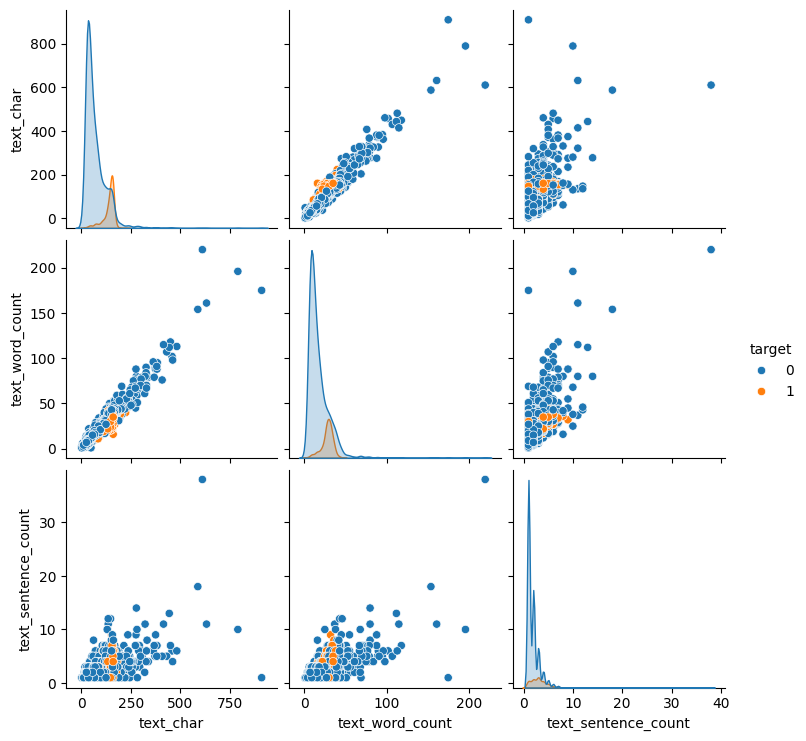

In [62]:
#relashionship between text_char and text_word_count
plt.figure(figsize=(12,8))
sns.pairplot(df, hue='target')

In [70]:
# Calculate correlation only for numeric columns
correlation_matrix = df.corr(numeric_only=True)

# Display the matrix
print(correlation_matrix)

                       target  text_char  text_word_count  text_sentence_count
target               1.000000   0.384717         0.262912             0.263939
text_char            0.384717   1.000000         0.965760             0.624139
text_word_count      0.262912   0.965760         1.000000             0.679971
text_sentence_count  0.263939   0.624139         0.679971             1.000000


<Axes: >

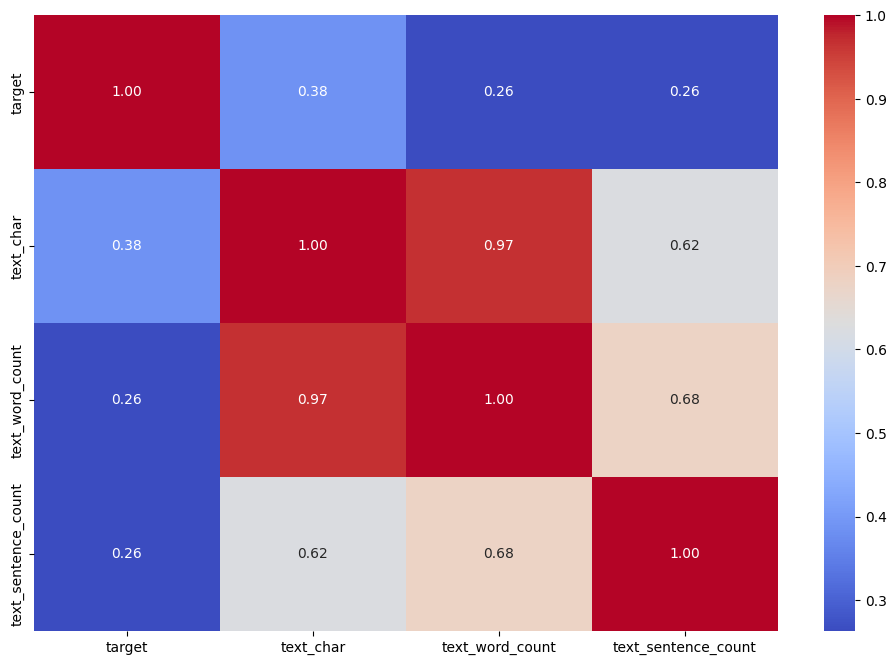

In [71]:
#heatmap of correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

# strong corelation so we use only text char 

## preprocessing of data

In [90]:
# stop words
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alpha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [111]:
# steamming
from nltk.stem import PorterStemmer
ps = PorterStemmer()


In [119]:
# lower case
# tokenization
#remove special characters
#remove stop words and punctuation
# stemming
def transform_lower_case(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)
           

In [120]:
#punctuation
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [121]:
transform_lower_case("Hello3e 4gv%d ?rew dat 9 > World! dancing")

'hello3 4gv rew dat 9 world danc'

In [122]:
# transform the text column

df['transformed_text'] = df['text'].apply(transform_lower_case)

In [123]:
df.head(10)

,target,text,text_char,text_word_count,text_sentence_count,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
5,1,FreeMsg Hey there darling it's been 3 week's n...,148,39,4,freemsg hey darl 3 week word back like fun sti...
6,0,Even my brother is not like to speak with me. ...,77,18,2,even brother like speak treat like aid patent
7,0,As per your request 'Melle Melle (Oru Minnamin...,160,31,2,per request mell oru minnaminungint nurungu ve...
8,1,WINNER!! As a valued network customer you have...,158,32,5,winner valu network custom select receivea pri...
9,1,Had your mobile 11 months or more? U R entitle...,154,31,3,mobil 11 month u r entitl updat latest colour ...


In [ ]:
from worldcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')